# Clasificador de Voz — Enojo vs Tristeza
## Features acústicos manuales · Dataset filtrado (10 vs 10)

**Objetivo:** Clasificar Enojo vs Tristeza a partir de features acústicos clásicos.  
**Dataset:** 20 audios filtrados por evidencia acústica (10 Enojo + 10 Tristeza).  
**Evaluación:** Leave-One-Out CV (LOOCV) — máxima honestidad con datasets pequeños.

| Sección | Contenido |
|---|---|
| 1–3 | Setup, extracción de features, carga del dataset |
| 4 | EDA: distribución, boxplots, espectrogramas |
| 5 | Modelado LOOCV |
| 6 | Diagnóstico: ¿recolector o emoción? |
| 7 | Separabilidad PCA / t-SNE |
| 8 | Conclusiones |

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_DIR = os.path.join('..', 'data', 'AUDIOS_FILTRADOS_V2')
REPORTE  = os.path.join('..', 'outputs', 'reporte_filtrado_v2.csv')
CLASES   = ['Enojo', 'Tristeza']
COLORES  = {'Enojo': '#DD8452', 'Tristeza': '#4C72B0'}
EXTS     = {'.ogg','.mp3','.mp4','.mpeg','.wav','.flac','.m4a'}
SR       = 22050
N_MFCC   = 13
HOP      = 1024   # hop_length mayor = más rápido

print('Configuración lista.')
print(f'Dataset: {DATA_DIR}')

Configuración lista.
Dataset: data/AUDIOS_FILTRADOS_V2


---
## 2. Extracción de features acústicos

| Grupo | Features | Dims |
|---|---|---|
| Pitch (F0) | media, std, p25, p75 | 4 |
| Energía RMS | media, std + tasa de silencio | 3 |
| ZCR | media, std | 2 |
| Spectral Centroid/Rolloff/Bandwidth | media, std × 3 | 6 |
| Spectral Contrast (7 bandas) | media, std | 14 |
| Chroma (12 clases) | media, std | 24 |
| MFCCs (13 coef.) | percentiles p10/25/50/75/90 | 65 |
| Delta MFCCs | media, std | 26 |
| **Total** | | **144** |

In [2]:
def extraer_features(ruta, sr=SR, n_mfcc=N_MFCC, hop=HOP):
    try:
        y, _ = librosa.load(ruta, sr=sr, mono=True, duration=15.0)
        if len(y) < sr * 0.1: return None
        f = []
        # Pitch
        f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'),
                            fmax=librosa.note_to_hz('C7'), hop_length=hop)
        f0v = f0[f0 > 0] if (f0 > 0).any() else np.array([0.0])
        f += [np.mean(f0v), np.std(f0v), np.percentile(f0v, 25), np.percentile(f0v, 75)]
        # RMS + silencio
        rms = librosa.feature.rms(y=y, hop_length=hop)[0]
        umb = 0.1 * np.max(rms) if np.max(rms) > 0 else 0
        f += [np.mean(rms), np.std(rms), np.mean(rms < umb)]
        # ZCR
        zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop)[0]
        f += [np.mean(zcr), np.std(zcr)]
        # Spectral
        for fn in [librosa.feature.spectral_centroid,
                   librosa.feature.spectral_rolloff,
                   librosa.feature.spectral_bandwidth]:
            s = fn(y=y, sr=sr, hop_length=hop)[0]
            f += [np.mean(s), np.std(s)]
        # Spectral contrast
        sct = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=hop)
        f += list(np.mean(sct, 1)) + list(np.std(sct, 1))
        # Chroma
        ch = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=hop)
        f += list(np.mean(ch, 1)) + list(np.std(ch, 1))
        # MFCCs con percentiles
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop)
        for p in [10, 25, 50, 75, 90]:
            f += list(np.percentile(mfcc, p, axis=1))
        # Delta MFCCs
        d1 = librosa.feature.delta(mfcc)
        f += list(np.mean(d1, 1)) + list(np.std(d1, 1))
        return np.array(f, dtype=np.float32)
    except Exception as e:
        print(f'  [WARN] {os.path.basename(ruta)}: {e}')
        return None

# Verificar dimensión con un audio de prueba
_test_ruta = os.path.join(DATA_DIR, 'Enojo',
    next(f for f in sorted(os.listdir(os.path.join(DATA_DIR, 'Enojo')))
         if os.path.splitext(f)[1].lower() in EXTS))
_test = extraer_features(_test_ruta)
print(f'Función lista. Dimensión del vector: {_test.shape[0]}')

Función lista. Dimensión del vector: 144


---
## 3. Carga del dataset filtrado

Usamos  para seleccionar exactamente los 10 mejores Enojo
y los 10 Tristeza que pasaron el filtro acústico.

In [3]:
df_rep = pd.read_csv(REPORTE)

# Top 10 Enojo por score_enojo, todos los Tristeza
top10_enojo   = (df_rep[df_rep['destino']=='Enojo']
                 .sort_values('score_enojo', ascending=False)
                 .head(10)['archivo'].tolist())
top10_tristeza = df_rep[df_rep['destino']=='Tristeza']['archivo'].tolist()

print(f'Enojo    ({len(top10_enojo)}): {top10_enojo}')
print(f'Tristeza ({len(top10_tristeza)}): {top10_tristeza}')

registros = []
for clase, archivos in [('Enojo', top10_enojo), ('Tristeza', top10_tristeza)]:
    for nombre in archivos:
        ruta = os.path.join(DATA_DIR, clase, nombre)
        if not os.path.exists(ruta):
            print(f'  [WARN] No encontrado: {ruta}')
            continue
        vec = extraer_features(ruta)
        if vec is not None:
            registros.append({'archivo': nombre, 'clase': clase,
                               'recolector': nombre[:2], 'features': vec})
            print(f'  OK  {clase}/{nombre}', flush=True)

X   = np.vstack([r['features']  for r in registros])
y   = np.array([r['clase']      for r in registros])
rec = np.array([r['recolector'] for r in registros])
le  = LabelEncoder()
y_enc = le.fit_transform(y)
X_sc  = StandardScaler().fit_transform(X)

print(f'Dataset: {X.shape[0]} muestras x {X.shape[1]} features')
print(f'Clases: {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'Recolectores: {dict(zip(*np.unique(rec, return_counts=True)))}')

Enojo    (10): ['VZ_02_ENO.ogg', 'MT_05_ENO.ogg', 'MT_03_ENO.ogg', 'MT_10_ENO.ogg', 'MT_02_ENO.ogg', 'MT_06_ENO.ogg', 'MT_07_ENO.ogg', 'MT_09_ENO.ogg', 'VZ_08_ENO.ogg', 'MT_01_ENO.ogg']
Tristeza (10): ['MT_03_TRI.ogg', 'MT_05_TRI.ogg', 'MT_06_TRI.ogg', 'MT_11.mp3_TRI.mpeg', 'VZ_01_TRI.mp4', 'VZ_02_TRI.ogg', 'VZ_04_TRI.ogg', 'VZ_07_TRI.ogg', 'VZ_08_TRI.ogg', 'VZ_09_TRI.ogg']
  OK  Enojo/VZ_02_ENO.ogg


  OK  Enojo/MT_05_ENO.ogg


  OK  Enojo/MT_03_ENO.ogg


  OK  Enojo/MT_10_ENO.ogg


  OK  Enojo/MT_02_ENO.ogg


...

  OK  Tristeza/VZ_04_TRI.ogg


  OK  Tristeza/VZ_07_TRI.ogg


  OK  Tristeza/VZ_08_TRI.ogg


  OK  Tristeza/VZ_09_TRI.ogg


Dataset: 20 muestras x 144 features
Clases: {np.str_('Enojo'): np.int64(10), np.str_('Tristeza'): np.int64(10)}
Recolectores: {np.str_('MT'): np.int64(12), np.str_('VZ'): np.int64(8)}


---
## 4. Análisis Exploratorio (EDA)

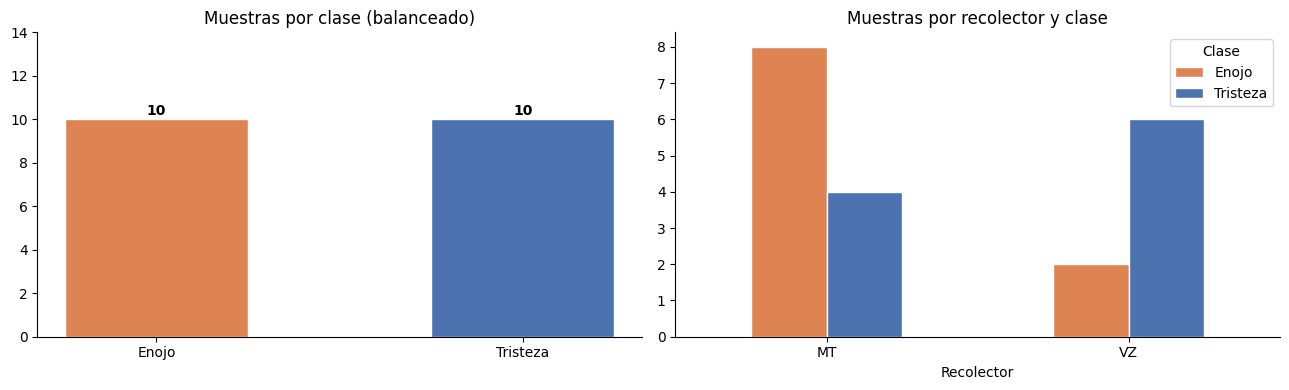

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barplot por clase
conteo = pd.Series(y).value_counts().reindex(CLASES)
axes[0].bar(conteo.index, conteo.values,
            color=[COLORES[c] for c in conteo.index], edgecolor='white', width=0.5)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')
axes[0].set_title('Muestras por clase (balanceado)')
axes[0].set_ylim(0, 14)
axes[0].spines[['top','right']].set_visible(False)

# Barplot por recolector x clase
pd.crosstab(pd.Series(rec, name='Recolector'),
            pd.Series(y,   name='Clase')).plot(
    kind='bar', ax=axes[1], color=[COLORES[c] for c in CLASES],
    edgecolor='white', rot=0)
axes[1].set_title('Muestras por recolector y clase')
axes[1].legend(title='Clase', bbox_to_anchor=(1, 1))
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

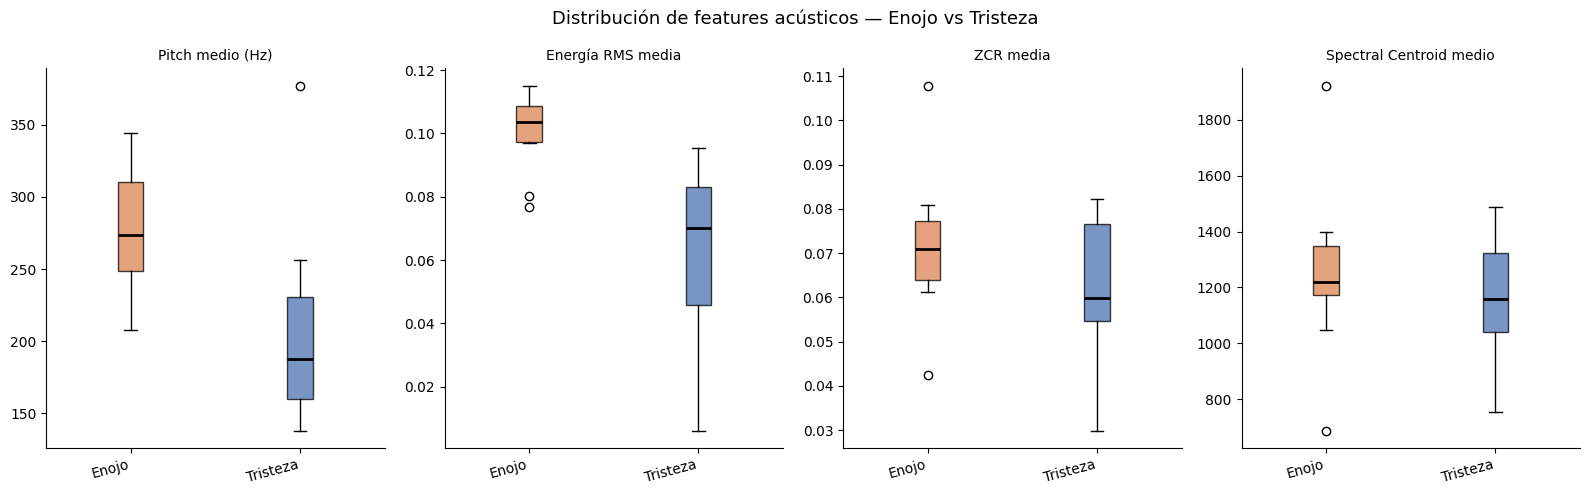

In [5]:
# Boxplots de features clave por clase
feat_idx    = [0, 4, 7, 9]
feat_labels = ['Pitch medio (Hz)', 'Energía RMS media',
               'ZCR media', 'Spectral Centroid medio']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, idx, label in zip(axes, feat_idx, feat_labels):
    datos = [X[y == c, idx] for c in CLASES]
    bp = ax.boxplot(datos, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], CLASES):
        patch.set_facecolor(COLORES[c]); patch.set_alpha(0.75)
    ax.set_xticklabels(CLASES, rotation=15, ha='right', fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Distribución de features acústicos — Enojo vs Tristeza', fontsize=13)
plt.tight_layout()
plt.show()

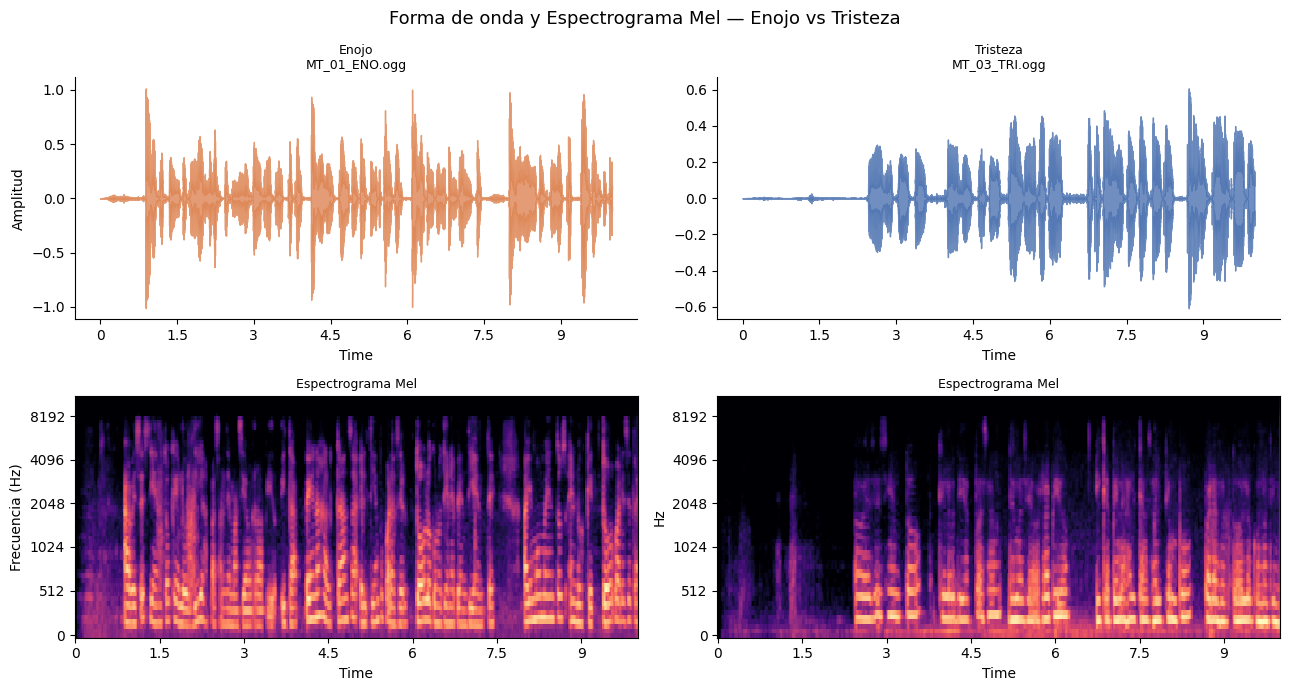

In [6]:
# Espectrogramas Mel — un ejemplo por clase
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, clase in enumerate(CLASES):
    ruta = os.path.join(DATA_DIR, clase,
        next(f for f in sorted(os.listdir(os.path.join(DATA_DIR, clase)))
             if os.path.splitext(f)[1].lower() in EXTS))
    ya, sra = librosa.load(ruta, sr=SR, mono=True, duration=10.0)
    librosa.display.waveshow(ya, sr=sra, ax=axes[0, col],
                              color=list(COLORES.values())[col], alpha=0.8)
    titulo = clase + '\n' + os.path.basename(ruta)
    axes[0, col].set_title(titulo, fontsize=9)
    axes[0, col].spines[['top','right']].set_visible(False)
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=ya, sr=sra, n_mels=64), ref=np.max)
    librosa.display.specshow(S, sr=sra, x_axis='time', y_axis='mel',
                              ax=axes[1, col], cmap='magma')
    axes[1, col].set_title('Espectrograma Mel', fontsize=9)
axes[0, 0].set_ylabel('Amplitud')
axes[1, 0].set_ylabel('Frecuencia (Hz)')
fig.suptitle('Forma de onda y Espectrograma Mel — Enojo vs Tristeza', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Modelado con features manuales — LOOCV

**Leave-One-Out CV:** con 20 muestras, entrena con 19 y predice 1, repitiendo 20 veces.
Es la estimación más honesta posible con un dataset tan pequeño.

In [7]:
loo = LeaveOneOut()
modelos = {
    'Baseline':   Pipeline([('s', StandardScaler()), ('c', DummyClassifier(strategy='most_frequent'))]),
    'KNN (k=3)':  Pipeline([('s', StandardScaler()), ('c', KNeighborsClassifier(n_neighbors=3))]),
    'KNN (k=5)':  Pipeline([('s', StandardScaler()), ('c', KNeighborsClassifier(n_neighbors=5))]),
    'SVM lineal': Pipeline([('s', StandardScaler()), ('c', SVC(kernel='linear', C=1, class_weight='balanced', random_state=42))]),
    'SVM RBF':    Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42))]),
    'LogReg':     Pipeline([('s', StandardScaler()), ('c', LogisticRegression(max_iter=2000, C=1, class_weight='balanced', random_state=42))]),
    'RF':         Pipeline([('s', StandardScaler()), ('c', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))]),
}

print('LOOCV — Features manuales (' + str(X.shape[1]) + ' dims)')
print('Chance baseline: 0.500 (2 clases balanceadas)')
print('{:<15} {:>8} {:>8} {:>10}  {}'.format('Modelo','Acc','BalAcc','Errores','vs chance'))
print('-'*58)

res_manual = {}
for nombre, pipe in modelos.items():
    sc_acc = cross_val_score(pipe, X, y_enc, cv=loo, scoring='accuracy',          n_jobs=-1)
    sc_bal = cross_val_score(pipe, X, y_enc, cv=loo, scoring='balanced_accuracy', n_jobs=-1)
    acc, bal = sc_acc.mean(), sc_bal.mean()
    err   = int(round((1 - acc) * len(y)))
    delta = bal - 0.5
    res_manual[nombre] = bal
    marca = ' ▲' if delta > 0.10 else (' ▼' if delta < -0.02 else '')
    print('{:<15} {:>8.4f} {:>8.4f} {:>6}/{:}  {:+.4f}{}'.format(nombre, acc, bal, err, len(y), delta, marca))

LOOCV — Features manuales (144 dims)
Chance baseline: 0.500 (2 clases balanceadas)
Modelo               Acc   BalAcc    Errores  vs chance
----------------------------------------------------------


Baseline          0.0000   0.0000     20/20  -0.5000 ▼
KNN (k=3)         0.7500   0.7500      5/20  +0.2500 ▲


KNN (k=5)         0.8500   0.8500      3/20  +0.3500 ▲
SVM lineal        0.8500   0.8500      3/20  +0.3500 ▲
SVM RBF           0.8000   0.8000      4/20  +0.3000 ▲
LogReg            0.8500   0.8500      3/20  +0.3500 ▲


RF                0.8500   0.8500      3/20  +0.3500 ▲


Mejor modelo: KNN (k=5)  (BalAcc=0.85)
              precision    recall  f1-score   support

       Enojo       0.82      0.90      0.86        10
    Tristeza       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



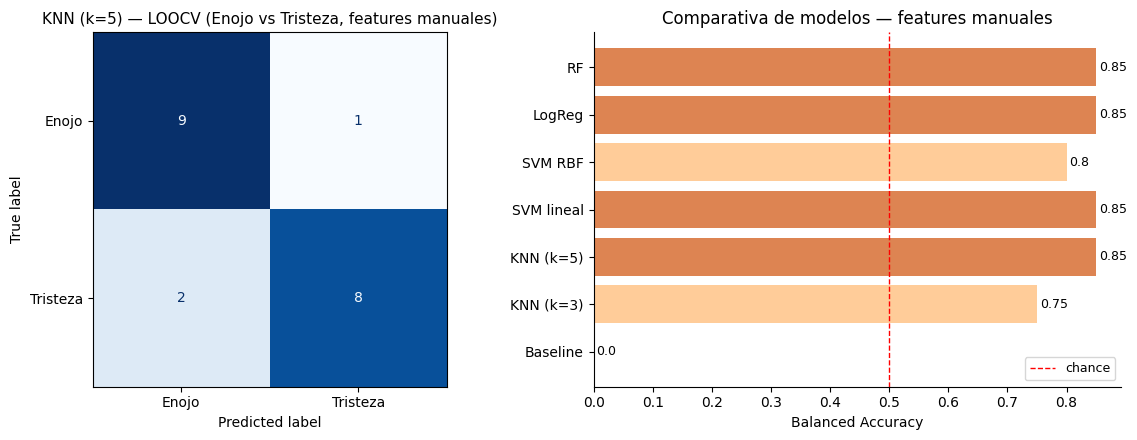

In [8]:
mejor  = max({k: v for k, v in res_manual.items() if k != 'Baseline'}, key=lambda k: res_manual[k])
pipe_m = modelos[mejor]
y_pred = np.zeros(len(y_enc), dtype=int)
for tr, te in loo.split(X):
    pipe_m.fit(X[tr], y_enc[tr])
    y_pred[te] = pipe_m.predict(X[te])

print('Mejor modelo: ' + mejor + '  (BalAcc=' + str(round(res_manual[mejor],4)) + ')')
print(classification_report(y_enc, y_pred, target_names=le.classes_, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cm = confusion_matrix(y_enc, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
titulo_cm = mejor + ' — LOOCV (Enojo vs Tristeza, features manuales)'
axes[0].set_title(titulo_cm, fontsize=11)

nombres_g = list(res_manual.keys())
vals_g    = [res_manual[n] for n in nombres_g]
best_val  = max(v for k, v in res_manual.items() if k != 'Baseline')
colores_g = ['#999' if n == 'Baseline' else '#DD8452' if res_manual[n] == best_val else '#FFCC99' for n in nombres_g]
axes[1].barh(nombres_g, vals_g, color=colores_g)
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='chance')
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_title('Comparativa de modelos — features manuales')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)
for i, v in enumerate(vals_g):
    axes[1].text(v + 0.005, i, str(round(v,3)), va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Diagnóstico — ¿Recolector o emoción?

Si el modelo clasifica mejor al recolector (MT vs VZ) que a la emoción,
los features están capturando condiciones de grabación, no emoción.

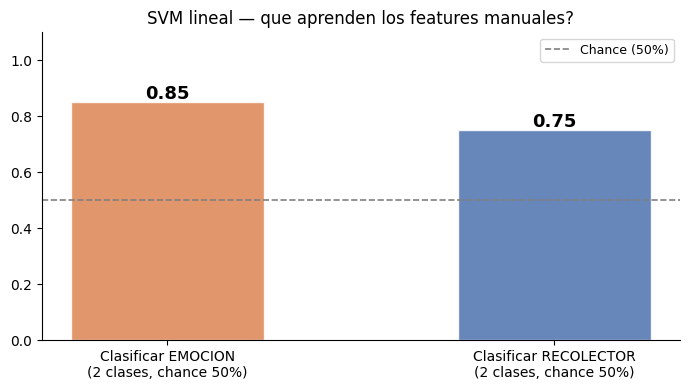

Clasificar EMOCION    (chance 50%): 0.85
Clasificar RECOLECTOR (chance 50%): 0.75
Los features capturan emocion, no solo identidad del recolector.


In [9]:
pipe_diag = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='linear', C=1, random_state=42))])
y_rec_enc = LabelEncoder().fit_transform(rec)

acc_emo = cross_val_score(pipe_diag, X, y_enc,     cv=loo, scoring='accuracy', n_jobs=-1).mean()
acc_rec = cross_val_score(pipe_diag, X, y_rec_enc, cv=loo, scoring='accuracy', n_jobs=-1).mean()

fig, ax = plt.subplots(figsize=(7, 4))
etiquetas = ['Clasificar EMOCION\n(2 clases, chance 50%)',
             'Clasificar RECOLECTOR\n(2 clases, chance 50%)']
bars = ax.bar(etiquetas, [acc_emo, acc_rec],
              color=['#DD8452', '#4C72B0'], alpha=0.85, edgecolor='white', width=0.5)
for bar, v in zip(bars, [acc_emo, acc_rec]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            str(round(v,3)), ha='center', fontsize=13, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Chance (50%)')
ax.set_ylim(0, 1.1)
ax.set_title('SVM lineal — que aprenden los features manuales?', fontsize=12)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Clasificar EMOCION    (chance 50%): ' + str(round(acc_emo,4)))
print('Clasificar RECOLECTOR (chance 50%): ' + str(round(acc_rec,4)))
if acc_rec > acc_emo + 0.1:
    print('Los features capturan mas al recolector que la emocion.')
else:
    print('Los features capturan emocion, no solo identidad del recolector.')

---
## 7. Separabilidad visual — PCA y t-SNE

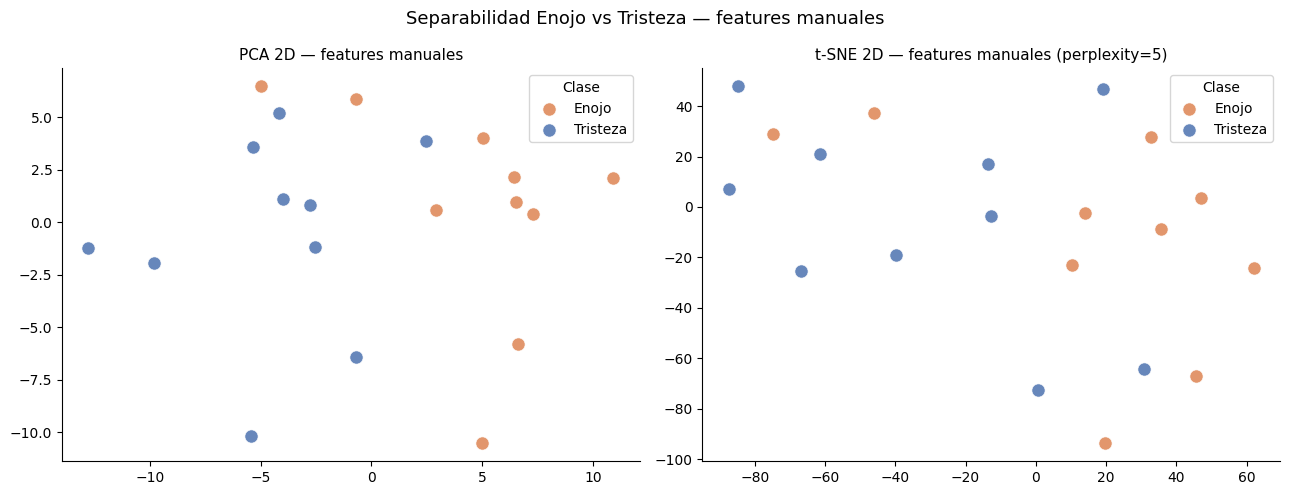

PCA: 11 componentes explican el 90% de la varianza (de 144 features)


In [10]:
X_pca  = PCA(n_components=2, random_state=42).fit_transform(X_sc)
X_tsne = TSNE(n_components=2, perplexity=5, random_state=42,
              max_iter=1000, init='pca', learning_rate='auto').fit_transform(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, datos, titulo in [
    (axes[0], X_pca,  'PCA 2D — features manuales'),
    (axes[1], X_tsne, 't-SNE 2D — features manuales (perplexity=5)'),
]:
    for clase, color in COLORES.items():
        mask = y == clase
        ax.scatter(datos[mask, 0], datos[mask, 1], c=color, label=clase,
                   s=90, alpha=0.85, edgecolors='white', linewidths=0.5)
    ax.set_title(titulo, fontsize=11)
    ax.legend(title='Clase')
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Separabilidad Enojo vs Tristeza — features manuales', fontsize=13)
plt.tight_layout()
plt.show()

pca_full = PCA(random_state=42).fit(X_sc)
var_acum = np.cumsum(pca_full.explained_variance_ratio_) * 100
n90 = np.searchsorted(var_acum, 90) + 1
print(f'PCA: {n90} componentes explican el 90% de la varianza (de {X_sc.shape[1]} features)')